In [209]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, matthews_corrcoef
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import copy 

In [210]:
df = pd.read_csv('data/synthetic_data.csv')

# Видалити рядки, де цільове значення відсутнє
df = df[df['Health_Issues'].notna()].copy()


In [235]:
print("Розмір даних:", df.shape)
df.info()
display(df.head())

print("\nПропущені значення:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nСтатистика:")
display(df.describe().T)

print("\nКатегоріальна статистика (object/category):")
try:
    display(df.describe(include=['object', 'category']).T)
except ValueError:
    print("Категоріальних колонок немає.")

Розмір даних: (4059, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 4059 entries, 2 to 9996
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       4059 non-null   int64  
 1   Age                      4059 non-null   int64  
 2   Gender                   4059 non-null   object 
 3   Country                  4059 non-null   object 
 4   Coffee_Intake            4059 non-null   float64
 5   Caffeine_mg              4059 non-null   float64
 6   Sleep_Hours              4059 non-null   float64
 7   Sleep_Quality            4059 non-null   object 
 8   BMI                      4059 non-null   float64
 9   Heart_Rate               4059 non-null   int64  
 10  Stress_Level             4059 non-null   object 
 11  Physical_Activity_Hours  4059 non-null   float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               4059 non-null   object 
 14  Smok

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
6,7,53,Male,France,2.7,252.1,7.8,Good,24.3,58,Low,1.0,Mild,Student,1,0
7,8,44,Female,Canada,4.5,423.5,5.5,Fair,15.8,62,Medium,0.7,Mild,Service,1,1



Пропущені значення:
Series([], dtype: int64)

Статистика:


,count,mean,std,min,25%,50%,75%,max
ID,4059.0,5008.735403,2872.905523,3.0,2511.5,5031.0,7497.5,9997.0
Age,4059.0,38.009116,12.914080,18.0,28.0,37.0,49.0,80.0
Coffee_Intake,4059.0,2.702365,1.470565,0.0,1.6,2.7,3.7,7.8
Caffeine_mg,4059.0,256.802735,139.660870,0.0,155.2,255.0,351.3,742.2
Sleep_Hours,4059.0,5.748904,1.134653,3.0,5.0,5.6,6.1,10.0
BMI,4059.0,24.722567,4.363655,15.0,21.7,24.5,27.7,38.2
Heart_Rate,4059.0,70.874600,9.780982,50.0,64.0,71.0,78.0,103.0
Physical_Activity_Hours,4059.0,7.446612,4.325022,0.0,3.7,7.4,11.2,15.0
Smoking,4059.0,0.196600,0.397476,0.0,0.0,0.0,0.0,1.0
Alcohol_Consumption,4059.0,0.294900,0.456054,0.0,0.0,0.0,1.0,1.0



Категоріальна статистика (object/category):


,count,unique,top,freq
Gender,4059,3,Female,2047
Country,4059,20,China,233
Sleep_Quality,4059,4,Fair,2050
Stress_Level,4059,3,Medium,2050
Health_Issues,4059,3,Mild,3579
Occupation,4059,5,Office,833


In [212]:
X = df.drop(['ID', 'Health_Issues'], axis=1)
y = df['Health_Issues'].copy()

# encode target
le_y = LabelEncoder()
y = le_y.fit_transform(y)


In [ ]:
cat_cols = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level',
            'Occupation', 'Smoking', 'Alcohol_Consumption']

num_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours',
            'BMI', 'Heart_Rate', 'Physical_Activity_Hours']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_cat = pd.DataFrame(ohe.fit_transform(X[cat_cols]),
                     columns=ohe.get_feature_names_out(cat_cols),
                     index=X.index)

X_num = X[num_cols].reset_index(drop=True)
X = pd.concat([X_num, X_cat.reset_index(drop=True)], axis=1)

feature_names = X.columns.tolist()


In [222]:
print("Перші 5 рядків після кодування:")
display(X.head())

Перші 5 рядків після кодування:


,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Gender_Female,Gender_Male,Gender_Other,...,Stress_Level_Medium,Occupation_Healthcare,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student,Smoking_0,Smoking_1,Alcohol_Consumption_0,Alcohol_Consumption_1
0,42,5.3,503.7,5.9,22.7,59,11.2,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,53,2.6,249.2,7.3,24.7,71,6.6,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,32,3.1,298.0,5.3,24.1,76,8.5,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,53,2.7,252.1,7.8,24.3,58,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,44,4.5,423.5,5.5,15.8,62,0.7,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [214]:
# спліт даних
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

#масштабування
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
class MyDecisionTree:
    def __init__(self, max_depth=None, min_samples=1):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_total = None

    def gini(self, y):
        if len(y) == 0:
            return 0.0
        p = np.bincount(y) / len(y)
        return 1.0 - np.sum(p ** 2)

    def best_split(self, X, y):
        n, m = X.shape
        if n <= 1:
            return None, None, None
        parent_gini = self.gini(y)
        best_impurity = np.inf
        best_feature = None
        best_threshold = None
        for feature in range(m):
            vals = X[:, feature]
            sorted_idx = np.argsort(vals)
            sorted_vals = vals[sorted_idx]
            sorted_y = y[sorted_idx]
            # Перебір порогів між різними значеннями
            for i in range(1, n):
                if sorted_vals[i] == sorted_vals[i-1]:
                    continue
                thr = 0.5 * (sorted_vals[i] + sorted_vals[i-1])
                left_y = sorted_y[:i]
                right_y = sorted_y[i:]
                if len(left_y) == 0 or len(right_y) == 0:
                    continue
                impurity = (len(left_y)/n)*self.gini(left_y) + (len(right_y)/n)*self.gini(right_y)
                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = thr
        return best_feature, best_threshold, best_impurity

    def build_tree(self, X, y, depth=0):
        n = len(y)
        majority = int(np.argmax(np.bincount(y)))
        # Умови зупинки
        if n < self.min_samples or (self.max_depth is not None and depth >= self.max_depth) or len(np.unique(y)) == 1:
            return {'leaf': True, 'class': majority, 'n': n}
        feature, thr, imp = self.best_split(X, y)
        if feature is None:
            return {'leaf': True, 'class': majority, 'n': n}
        left_idx = X[:, feature] <= thr
        right_idx = ~left_idx
        left_sub = self.build_tree(X[left_idx], y[left_idx], depth+1)
        right_sub = self.build_tree(X[right_idx], y[right_idx], depth+1)
        return {'leaf': False, 'feature': feature, 'threshold': thr,
                'left': left_sub, 'right': right_sub, 'class': majority, 'n': n}

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y, dtype=int)
        self.n_total = len(y)
        self.feature_importance = np.zeros(X.shape[1])
        self.tree = self.build_tree(X, y, depth=0)
        return self

    def predict_one(self, x, node):
        if node['leaf']:
            return node['class']
        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self.predict_one(x, self.tree) for x in X])

    def score(self, X, y):
        y_pred = self.predict(X)
        return float(np.mean(y_pred == y))

    # підрахунок листків
    def count_leaves(self, node):
        if node['leaf']:
            return 1
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])
    
    # підрахунок error
    def calc_error_node(self, node, X_val, y_val):
        y_pred = np.array([self._pred_with_node(xi, node) for xi in np.asarray(X_val)])
        return np.mean(y_pred != y_val)

    # підрахунок передбачень для одного зразка з вказаним вузлом
    def _pred_with_node(self, x, node):
        if node['leaf']:
            return node['class']
        if x[node['feature']] <= node['threshold']:
            return self._pred_with_node(x, node['left'])
        else:
            return self._pred_with_node(x, node['right'])

    # Post-pruning: для кожного піддерева вирішуємо чи замінити на лист на validation
    def prune_tree(self, node, alpha, X_val, y_val):
        # Якщо даних у цьому вузлі немає, ми нічого не можемо сказати -> не чіпаємо
        if len(y_val) == 0:
            if node['leaf']:
                return 0, 1 # 0 помилок, 1 лист
            # Якщо це вузол, треба повернути суму листків під ним
            return 0, self.count_leaves(node)

        # 1. Якщо це вже лист, рахуємо помилки
        if node['leaf']:
            # Кількість неправильних прогнозів у цьому листі
            mistakes = np.sum(y_val != node['class'])
            return mistakes, 1

        # Якщо це вузол розгалуження, спускаємо дані дітям
        # Фільтруємо дані за умовою вузла
        idx_left = X_val[:, node['feature']] <= node['threshold']
        idx_right = ~idx_left
        
        X_left, y_left = X_val[idx_left], y_val[idx_left]
        X_right, y_right = X_val[idx_right], y_val[idx_right]

        # Рекурсивно йдемо вниз
        mistakes_left, leaves_left = self.prune_tree(node['left'], alpha, X_left, y_left)
        mistakes_right, leaves_right = self.prune_tree(node['right'], alpha, X_right, y_right)

        # Рахуємо статистику для ПІДДЕРЕВА
        subtree_mistakes = mistakes_left + mistakes_right
        subtree_leaves = leaves_left + leaves_right
        
        # Загальна кількість прикладів у валідації (для нормування)
        n_val = len(y_val)

        # Важливо: alpha застосовується до Error Rate, тому ділимо на len(y_val) або загальний N
        subtree_cost = (subtree_mistakes / n_val) + alpha * subtree_leaves

        # Якщо ми обріжемо, вузол стане листом з класом node['class'] (який ми зберегли при навчанні)
        leaf_mistakes = np.sum(y_val != node['class'])
        leaf_cost = (leaf_mistakes / n_val) + alpha * 1

        # рішення: різати чи ні
        if leaf_cost <= subtree_cost:
            # РІЖЕМО! (Змінюємо поточний вузол на лист)
            node.clear() # Видаляємо left, right, feature, threshold
            node['leaf'] = True
            node['class'] = int(np.argmax(np.bincount(y_val))) if len(y_val) > 0 else 0 
            
            # логіка clear:
            saved_class = int(np.argmax(np.bincount(y_val))) if len(y_val) > 0 else 0
            node['leaf'] = True
            node['class'] = saved_class
            
            return leaf_mistakes, 1
        else:
            # НЕ РІЖЕМО, залишаємо як є
            return subtree_mistakes, subtree_leaves

In [ ]:
# Пошук best_alpha за допомогою K-Fold CV
alphas = np.logspace(-4, -0.5, 8)  # можна розширити
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_alpha = None
best_score = -np.inf

for alpha in alphas:
    fold_scores = []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr_fold, X_val_fold = X_train[tr_idx], X_train[val_idx]
        y_tr_fold, y_val_fold = y_train[tr_idx], y_train[val_idx]

        # SMOTE тільки на train fold
        sm = SMOTE(random_state=42)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_fold, y_tr_fold)

        # Фітимо дерево на train_fold (after SMOTE)
        tree_cv = MyDecisionTree(max_depth=None, min_samples=2)
        tree_cv.fit(X_tr_sm, y_tr_sm)

        # Прунім дерево з alpha використовуючи ВАЛІДАЦІЮ фолду
        # Копіюємо дерево, щоб не ламати оригінал
        tree_copy = copy.deepcopy(tree_cv)
        _ = tree_copy.prune_tree(tree_copy.tree, alpha, X_val_fold, y_val_fold)

        # Оцінка на валідаційному фолді
        val_score = tree_copy.score(X_val_fold, y_val_fold)
        fold_scores.append(val_score)

    mean_fold_score = np.mean(fold_scores)
    print(f"alpha={alpha:.6f}, CV mean score={mean_fold_score:.4f}")
    if mean_fold_score > best_score:
        best_score = mean_fold_score
        best_alpha = alpha

print("Best alpha (CV):", best_alpha, "with CV score:", best_score)


alpha=0.000100, CV mean score=0.9957
alpha=0.000316, CV mean score=0.9948
alpha=0.001000, CV mean score=0.9929
alpha=0.003162, CV mean score=0.9929
alpha=0.010000, CV mean score=0.9338
alpha=0.031623, CV mean score=0.8817
alpha=0.100000, CV mean score=0.8817
alpha=0.316228, CV mean score=0.8817
Best alpha (CV): 0.0001 with CV score: 0.9956875666706175


/tmp/ipykernel_116328/3976948591.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=original_counts.index, y=original_counts.values, ax=axes[0], palette="Blues_d")
/tmp/ipykernel_116328/3976948591.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bal_counts.index, y=bal_counts.values, ax=axes[1], palette="viridis")


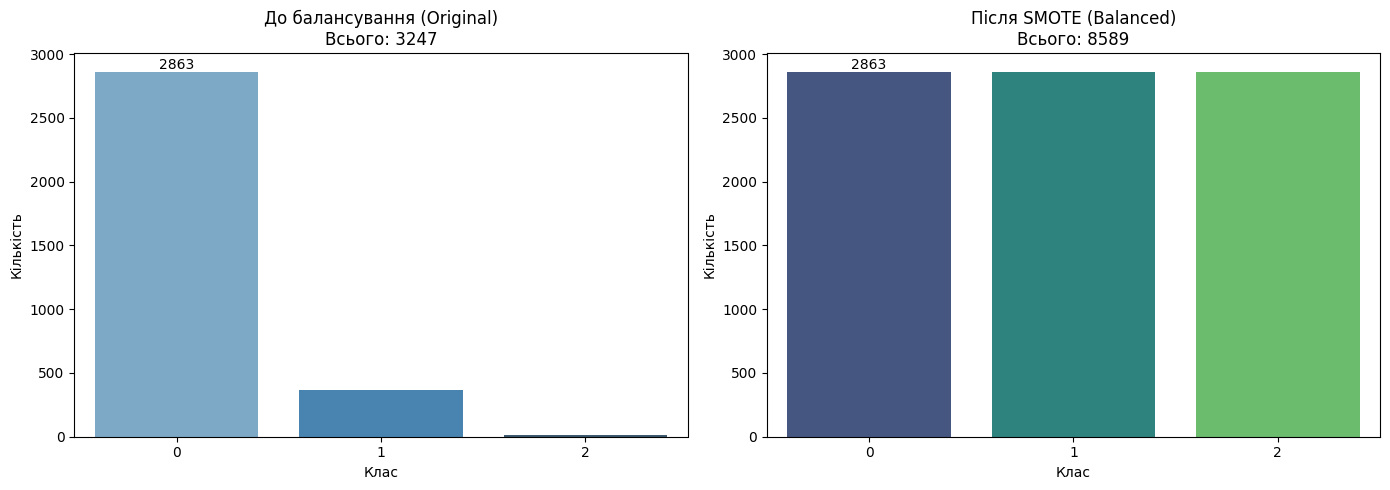

До Smote
0    2863
1     370
2      14
Name: count, dtype: int64
Після Smote
0    2863
1    2863
2    2863
Name: count, dtype: int64


=== Final MyDecisionTree Results ===
Accuracy: 0.9470443349753694
F1 macro: 0.8578843226788432
MCC: 0.7897778731288331
Confusion matrix:
 [[679  37   0]
 [  5  88   0]
 [  0   1   2]]


Sensitivity (per class): [0.9483 0.9462 0.6667]
Specificity (per class): [0.9479 0.9471 1.    ]
Sensitivity (macro): 0.85374241605094
Specificity (macro): 0.9650218281563901
=== Final MyDecisionTree Results ===
Accuracy: 0.9470443349753694
F1 macro: 0.8578843226788432
MCC: 0.7897778731288331
Confusion matrix:
 [[679  37   0]
 [  5  88   0]
 [  0   1   2]]


Sensitivity (per class): [0.9483 0.9462 0.6667]
Specificity (per class): [0.9479 0.9471 1.    ]
Sensitivity (macro): 0.85374241605094
Specificity (macro): 0.9650218281563901


In [217]:
# Блок 10. Фінальний тренінг: SMOTE на ВСЬОМУ X_train, фіт, потім прунінг з best_alpha, оцінка на тесті
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: До SMOTE
original_counts = pd.Series(y_train).value_counts().sort_index()
sns.barplot(x=original_counts.index, y=original_counts.values, ax=axes[0], palette="Blues_d")
axes[0].set_title(f"До балансування (Original)\nВсього: {len(y_train)}")
axes[0].set_xlabel("Клас")
axes[0].set_ylabel("Кількість")
axes[0].bar_label(axes[0].containers[0]) # Додає цифри над стовпчиками

# Графік 2: Після SMOTE
bal_counts = pd.Series(y_train_bal).value_counts().sort_index()
sns.barplot(x=bal_counts.index, y=bal_counts.values, ax=axes[1], palette="viridis")
axes[1].set_title(f"Після SMOTE (Balanced)\nВсього: {len(y_train_bal)}")
axes[1].set_xlabel("Клас")
axes[1].set_ylabel("Кількість")
axes[1].bar_label(axes[1].containers[0])

plt.tight_layout()
plt.show()

print("До Smote")
print(original_counts)
print("Після Smote")
print(bal_counts)

print("\n")

final_tree = MyDecisionTree(max_depth=None, min_samples=2)
final_tree.fit(X_train_bal, y_train_bal)

# Прунінг з best_alpha, використовуємо X_train_bal як "validation" для локального рішення
# (alpha відібрано через CV; тут застосовуємо на повному трені)
_ = final_tree.prune_tree(final_tree.tree, best_alpha, X_train_bal, y_train_bal)

# Оцінка на test
y_pred = final_tree.predict(X_test)
print("=== Final MyDecisionTree Results ===")
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
mcc = matthews_corrcoef(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy:", acc)
print("F1 macro:", f1m)
print("MCC:", mcc)
print("Confusion matrix:\n", cm)

print("\n")

# Sensitivity/Specificity (пер-клас та macro)
sens_list = []
spec_list = []
for i in range(cm.shape[0]):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Recall for class i
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # True negative rate for class i
    sens_list.append(sens)
    spec_list.append(spec)

sens_arr = np.array(sens_list)
spec_arr = np.array(spec_list)
print("Sensitivity (per class):", np.round(sens_arr, 4))
print("Specificity (per class):", np.round(spec_arr, 4))
print("Sensitivity (macro):", float(np.mean(sens_arr)))
print("Specificity (macro):", float(np.mean(spec_arr)))


In [227]:
# Блок 11. Порівняння зі sklearn: DecisionTree + RandomForest (на тих же balanced train даних)

dt_sk = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=None)
dt_sk.fit(X_train_bal, y_train_bal)
y_pred_dt = dt_sk.predict(X_test)

rf_sk = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sk.fit(X_train_bal, y_train_bal)
y_pred_rf = rf_sk.predict(X_test)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    mcc = matthews_corrcoef(y_true, y_pred)

    n_classes = cm.shape[0]
    sensitivity = []
    specificity = []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        sensitivity.append(sens)
        specificity.append(spec)

    sensitivity = np.array(sensitivity)
    specificity = np.array(specificity)

    return {
        'accuracy': acc,
        'f1_macro': f1,
        'mcc': mcc,
        'confusion_matrix': cm,
        'sensitivity_per_class': sensitivity,
        'specificity_per_class': specificity,
        'sensitivity_macro': float(np.mean(sensitivity)),
        'specificity_macro': float(np.mean(specificity))
    }

metrics_dt = compute_metrics(y_test, y_pred_dt)
metrics_rf = compute_metrics(y_test, y_pred_rf)

# Print DT metrics
print("=== Sklearn DecisionTree ===")
print(f"Accuracy: {metrics_dt['accuracy']:.4f}")
print(f"F1 macro: {metrics_dt['f1_macro']:.4f}")
print(f"MCC: {metrics_dt['mcc']:.4f}")
print(f"Sensitivity (per class): {np.round(metrics_dt['sensitivity_per_class'], 4)}")
print(f"Specificity (per class): {np.round(metrics_dt['specificity_per_class'], 4)}")
print(f"Sensitivity (macro): {metrics_dt['sensitivity_macro']:.4f}")
print(f"Specificity (macro): {metrics_dt['specificity_macro']:.4f}")
print("Confusion matrix:\n", metrics_dt['confusion_matrix'])
print('\n')

# Print RF metrics
print("=== Sklearn RandomForest ===")
print(f"Accuracy: {metrics_rf['accuracy']:.4f}")
print(f"F1 macro: {metrics_rf['f1_macro']:.4f}")
print(f"MCC: {metrics_rf['mcc']:.4f}")
print(f"Sensitivity (per class): {np.round(metrics_rf['sensitivity_per_class'], 4)}")
print(f"Specificity (per class): {np.round(metrics_rf['specificity_per_class'], 4)}")
print(f"Sensitivity (macro): {metrics_rf['sensitivity_macro']:.4f}")
print(f"Specificity (macro): {metrics_rf['specificity_macro']:.4f}")
print("Confusion matrix:\n", metrics_rf['confusion_matrix'])

print("\n")

# CV для RandomForest (приклад, 5-fold на train_bal)
print("Running cross-val for RF (train_bal, 5-fold)...")
cv_score_rf = cross_val_score(rf_sk, X_train_bal, y_train_bal, cv=5).mean()
print("RF CV score (train_bal):", cv_score_rf)


=== Sklearn DecisionTree ===
Accuracy: 0.9483
F1 macro: 0.8594
MCC: 0.7935
Sensitivity (per class): [0.9497 0.9462 0.6667]
Specificity (per class): [0.9479 0.9485 1.    ]
Sensitivity (macro): 0.8542
Specificity (macro): 0.9655
Confusion matrix:
 [[680  36   0]
 [  5  88   0]
 [  0   1   2]]


=== Sklearn RandomForest ===
Accuracy: 0.9815
F1 macro: 0.6374
MCC: 0.9116
Sensitivity (per class): [0.9916 0.9355 0.    ]
Specificity (per class): [0.9375 0.9875 1.    ]
Sensitivity (macro): 0.6424
Specificity (macro): 0.9750
Confusion matrix:
 [[710   6   0]
 [  6  87   0]
 [  0   3   0]]


Running cross-val for RF (train_bal, 5-fold)...
RF CV score (train_bal): 0.9935964602417922


Top features indices: [ 4  0  3 38 35 40 10  8 31  7 32 41  6  1 36]


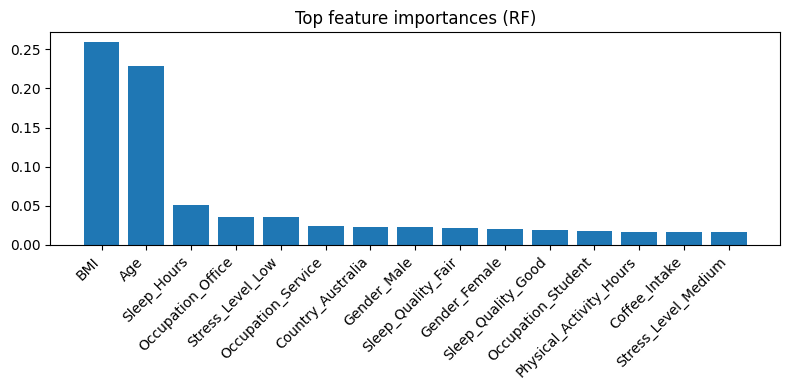

In [226]:
# Блок 12. Feature importance (RF) та відбір топ-10
importances = rf_sk.feature_importances_
indices = np.argsort(importances)[::-1]
top_k = 15
top_idx = indices[:top_k]


print("Top features indices:", top_idx)
# Візуалізація
plt.figure(figsize=(8,4))
plt.bar(range(top_k), importances[top_idx])
plt.xticks(range(top_k), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title("Top feature importances (RF)")
plt.tight_layout()
plt.show()


In [233]:
def show_metrics(y_true, y_pred, title):
    print(f"\n=== {title} ===")
    
    # Основні метрики
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    mcc = matthews_corrcoef(y_true, y_pred)
    
    print(f"Accuracy:    {acc:.4f}")
    print(f"F1 (Macro):  {f1:.4f}")
    print(f"MCC:         {mcc:.4f}")
    
    # Детальна статистика по класах
    cm = confusion_matrix(y_true, y_pred)
    print("-" * 40)
    print(f"{'Class':<10} {'Sens.':<10} {'Spec.':<10}")
    print("-" * 40)
    
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"{i:<10} {sensitivity:<10.4f} {specificity:<10.4f}")
    
    print("-" * 40)
    print("Confusion Matrix:\n", cm)


# Оцінка на всіх фічах
y_pred_all = final_tree.predict(X_test)
show_metrics(y_test, y_pred_all, "MyDecisionTree (All 46 Features)")

print("\n")

# нові вибірки
X_train_sel = X_train_bal[:, top_idx]
X_test_sel = X_test[:, top_idx]

# Навчаємо нове дерево
tree_sel = MyDecisionTree(max_depth=10, min_samples=2)
tree_sel.fit(X_train_sel, y_train_bal)

# Прогноз
y_pred_sel = tree_sel.predict(X_test_sel)

show_metrics(y_test, y_pred_sel, f"MyDecisionTree (Top-{top_k} Features)")


=== MyDecisionTree (All 46 Features) ===
Accuracy:    0.9470
F1 (Macro):  0.8579
MCC:         0.7898
----------------------------------------
Class      Sens.      Spec.     
----------------------------------------
0          0.9483     0.9479    
1          0.9462     0.9471    
2          0.6667     1.0000    
----------------------------------------
Confusion Matrix:
 [[679  37   0]
 [  5  88   0]
 [  0   1   2]]



=== MyDecisionTree (Top-15 Features) ===
Accuracy:    0.9581
F1 (Macro):  0.8730
MCC:         0.8327
----------------------------------------
Class      Sens.      Spec.     
----------------------------------------
0          0.9567     0.9792    
1          0.9785     0.9555    
2          0.6667     1.0000    
----------------------------------------
Confusion Matrix:
 [[685  31   0]
 [  2  91   0]
 [  0   1   2]]
